# Chapter 3. Structure of Semisimple Lie Algebras

**Source Span.** Helgason, *Differential Geometry, Lie Groups, and Symmetric Spaces*, Chapter III, printed pages 155-197 (approximately PDF pages 182-224).

This notebook is a standalone computational guide to the chapter. It does not reproduce the textbook's proofs or exercises; instead it rebuilds the main constructions through finite-dimensional models, diagrams, symbolic brackets, and sanity checks. The chapter's path is: triangularization for solvable algebras, nilpotence via Engel, regular elements and Cartan subalgebras, root-space decompositions, root strings, compact real forms, Cartan decompositions, and the classical complex root patterns.

The guiding question is: how does a semisimple Lie algebra become readable from a Cartan subalgebra and the finite geometry of its roots?


## Visual Storyboard and Library Routing

- Lie and Engel theorems: triangular matrix algebras show solvable and nilpotent chains terminating.
- Cartan subalgebras: diagonal matrices in `sl(3,C)` show regular versus singular centralizers.
- Root decomposition: `sl(3,C)` root spaces give a concrete `A2` root system.
- Root strings and reflections: simple roots, Cartan integers, and Weyl reflections become a finite vector diagram.
- Root pattern determines brackets: matrix commutators show when roots add and when the bracket is zero.
- Compact real forms and Cartan decompositions: `sl(2,R)` separates compact and noncompact directions by the Cartan involution.
- Classical examples: `A_n`, `B_n`, `C_n`, `D_n` are summarized by root formulas and small rank visuals.

**Library Routing.** SymPy carries exact bracket and root checks. NumPy handles finite vector calculations and signature tests. Matplotlib draws root systems, chain dimensions, and Cartan decomposition diagnostics. The local artifact helpers save PNG/CSV/JSON evidence under the Chapter 3 artifact subtree.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

_here = Path.cwd().resolve()
for candidate in [_here, *_here.parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the Helgason book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (  # noqa: E402
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "chapter-03-structure-of-semisimple-lie-algebras"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
TABLES = ARTIFACT_ROOT / "tables"
CHECKS = ARTIFACT_ROOT / "checks"

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

artifact_paths: list[Path] = []
chapter_checks: dict[str, bool | float | str] = {}

def rel(path: Path) -> str:
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()

def record(path: Path) -> Path:
    artifact_paths.append(Path(path))
    return Path(path)


In [2]:
storyboard = [
    {"source_sections": "1-2. Preliminaries, Lie, Engel", "witness": "derived and central descending chains for triangular algebras", "artifact": "figures/solvable_nilpotent_chains.png", "validation": "both chains terminate at zero"},
    {"source_sections": "3. Cartan subalgebras", "witness": "regular versus singular diagonal elements in sl3", "artifact": "figures/sl3_regular_centralizer_heatmap.png", "validation": "regular centralizer has Cartan dimension two"},
    {"source_sections": "4. Root space decomposition", "witness": "A2 root diagram and root-space table for sl3", "artifact": "figures/sl3_a2_root_system.png", "validation": "six nonzero roots and two-dimensional Cartan"},
    {"source_sections": "4-5. Root strings and root pattern", "witness": "Weyl reflection and Cartan matrix check", "artifact": "checks/a2_root_reflection_checks.json", "validation": "reflections preserve the root set"},
    {"source_sections": "5. Significance of root pattern", "witness": "sl3 commutator table for root addition", "artifact": "tables/sl3_root_commutator_table.csv", "validation": "root brackets land in alpha+beta or vanish"},
    {"source_sections": "6-7. Real forms and Cartan decompositions", "witness": "sl2R Cartan involution and Killing sign split", "artifact": "figures/sl2_cartan_decomposition_signs.png", "validation": "bracket relations k-k, k-p, p-p hold"},
    {"source_sections": "8. Classical complex Lie algebras", "witness": "A2, B2, C2 root visuals and root-count table", "artifact": "figures/classical_rank2_root_systems.png", "validation": "root count formulas match samples"},
]

coverage_rows = [
    {"source_part": "Preliminaries on semisimple and nilpotent endomorphisms", "captured_as": "triangular matrix diagnostics and chain dimensions", "notebook_section": "Lie and Engel chains"},
    {"source_part": "Lie theorem and Engel theorem", "captured_as": "solvable upper-triangular and nilpotent strictly-upper-triangular models", "notebook_section": "Lie and Engel chains"},
    {"source_part": "Cartan subalgebras", "captured_as": "regular diagonal element in sl3 and centralizer dimension check", "notebook_section": "Cartan subalgebras"},
    {"source_part": "Root space decomposition", "captured_as": "sl3 root table and A2 root diagram", "notebook_section": "Root decomposition"},
    {"source_part": "Root strings and simple roots", "captured_as": "A2 Cartan matrix, root strings, and Weyl reflection check", "notebook_section": "Root reflections"},
    {"source_part": "Root pattern determines algebra", "captured_as": "sl3 commutator table for root addition", "notebook_section": "Root pattern and brackets"},
    {"source_part": "Real forms and compact real form", "captured_as": "compact versus split real-form sign discussion through sl2", "notebook_section": "Cartan decomposition"},
    {"source_part": "Cartan decompositions", "captured_as": "sl2R theta decomposition, Killing sign split, bracket containment", "notebook_section": "Cartan decomposition"},
    {"source_part": "Classical complex Lie algebras", "captured_as": "root formulas, root count table, small rank diagrams", "notebook_section": "Classical root systems"},
]

storyboard_path = record(save_json(storyboard, CHECKS / "chapter_03_visual_storyboard.json"))
coverage_path = record(save_csv(coverage_rows, TABLES / "chapter_03_coverage_map.csv"))
print(json.dumps({"storyboard_items": len(storyboard), "coverage_rows": len(coverage_rows), "storyboard": rel(storyboard_path), "coverage": rel(coverage_path)}, indent=2))
display_artifact(coverage_path)


{
  "storyboard_items": 7,
  "coverage_rows": 9,
  "storyboard": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/checks/chapter_03_visual_storyboard.json",
  "coverage": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/tables/chapter_03_coverage_map.csv"
}


[chapter_03_coverage_map.csv](artifacts/chapter-03-structure-of-semisimple-lie-algebras/tables/chapter_03_coverage_map.csv)

## 1. Lie and Engel Theorems as Terminating Chains

Lie's theorem says that a solvable complex Lie algebra of endomorphisms can be simultaneously triangularized. Engel's theorem says that a Lie algebra acting by nilpotent endomorphisms has a common zero vector and admits a strictly upper-triangular form. The finite matrix algebras `t(n)` and `n(n)` make those two conclusions visible.

The plot tracks two descending chains. The derived series of upper triangular matrices terminates, showing solvability. The central descending series of strictly upper triangular matrices terminates, showing nilpotence.


{
  "figure": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/figures/solvable_nilpotent_chains.png",
  "table": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/tables/solvable_nilpotent_chain_dimensions.csv",
  "checks": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/checks/lie_engel_chain_checks.json"
}


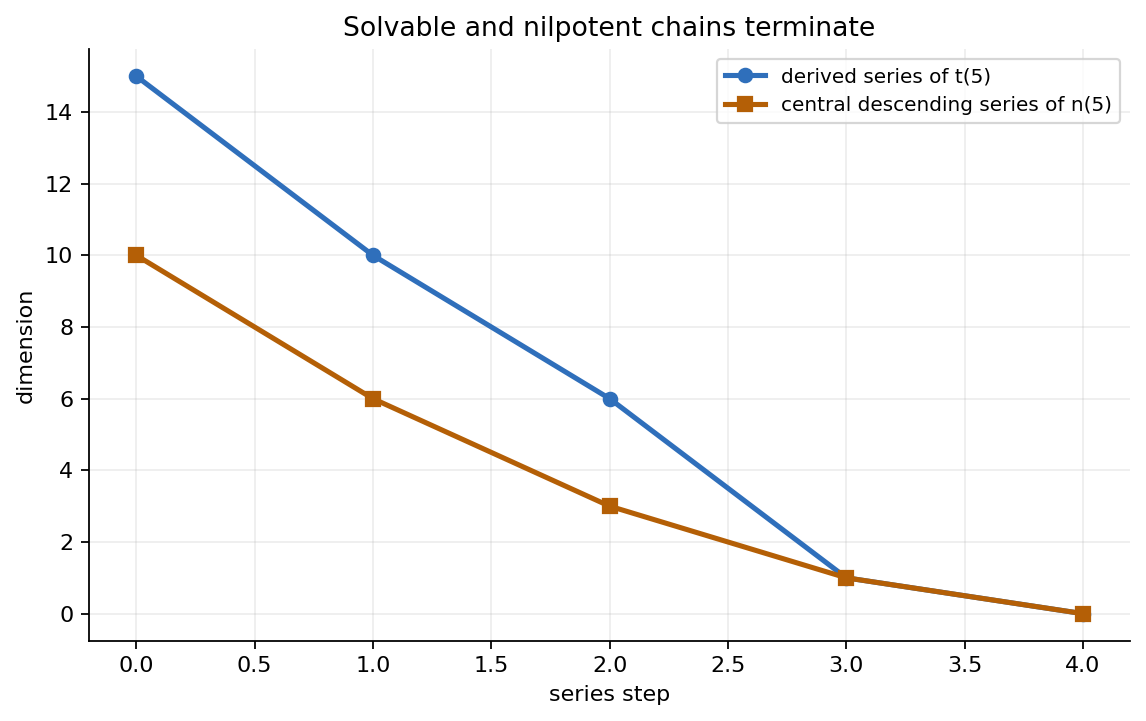

In [3]:
def dim_upper_with_min_gap(n: int, gap: int) -> int:
    if gap <= 0:
        return n * (n + 1) // 2
    return sum(max(n - d, 0) for d in range(gap, n))

n_chain = 5
derived_rows = []
gap = 0
for step in range(5):
    dim = dim_upper_with_min_gap(n_chain, gap)
    derived_rows.append({"series": "derived_tn", "step": step, "min_superdiagonal_gap": gap, "dimension": dim})
    gap = 1 if gap == 0 else 2 * gap

central_rows = []
for step, gap in enumerate(range(1, n_chain + 1)):
    central_rows.append({"series": "central_descending_nn", "step": step, "min_superdiagonal_gap": gap, "dimension": dim_upper_with_min_gap(n_chain, gap)})

chain_rows = derived_rows + central_rows
chain_table = record(save_csv(chain_rows, TABLES / "solvable_nilpotent_chain_dimensions.csv"))

fig, ax = plt.subplots(figsize=(8.4, 4.8))
ax.plot([r["step"] for r in derived_rows], [r["dimension"] for r in derived_rows], marker="o", linewidth=2.3, color="#2f6fbb", label="derived series of t(5)")
ax.plot([r["step"] for r in central_rows], [r["dimension"] for r in central_rows], marker="s", linewidth=2.3, color="#b45f06", label="central descending series of n(5)")
ax.set_title("Solvable and nilpotent chains terminate")
ax.set_xlabel("series step")
ax.set_ylabel("dimension")
ax.legend(fontsize=9)
chain_figure = record(save_matplotlib(fig, FIGURES / "solvable_nilpotent_chains.png"))
plt.close(fig)

chain_report = record(save_json({
    "n": n_chain,
    "derived_series": derived_rows,
    "central_descending_series": central_rows,
    "checks": {
        "derived_series_reaches_zero": derived_rows[-1]["dimension"] == 0,
        "central_descending_series_reaches_zero": central_rows[-1]["dimension"] == 0,
        "strict_upper_triangular_chain_has_nonzero_center": central_rows[-2]["dimension"] == 1,
    },
}, CHECKS / "lie_engel_chain_checks.json"))
chapter_checks["derived_series_reaches_zero"] = bool(derived_rows[-1]["dimension"] == 0)
chapter_checks["central_descending_series_reaches_zero"] = bool(central_rows[-1]["dimension"] == 0)
chapter_checks["nilpotent_model_has_nonzero_center"] = bool(central_rows[-2]["dimension"] == 1)
print(json.dumps({"figure": rel(chain_figure), "table": rel(chain_table), "checks": rel(chain_report)}, indent=2))
display_artifact(chain_figure)


## 2. Cartan Subalgebras and Regular Elements in `sl(3,C)`

Helgason proves the existence of Cartan subalgebras by examining regular elements and the generalized zero eigenspace of `ad H`. In `sl(3,C)`, diagonal trace-zero matrices form a Cartan subalgebra. A diagonal element with distinct diagonal entries is regular: its centralizer in `sl(3,C)` is exactly the two-dimensional diagonal Cartan. If two diagonal entries coincide, extra off-diagonal matrices commute with it, and the centralizer grows.

The heatmap shows the eigenvalues of `ad H` on matrix positions `E_ij`: the entry is `h_i - h_j`. Zeros off the diagonal reveal extra centralizer directions.


{
  "figure": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/figures/sl3_regular_centralizer_heatmap.png",
  "table": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/tables/sl3_regular_centralizer_table.csv",
  "checks": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/checks/sl3_cartan_regular_checks.json"
}


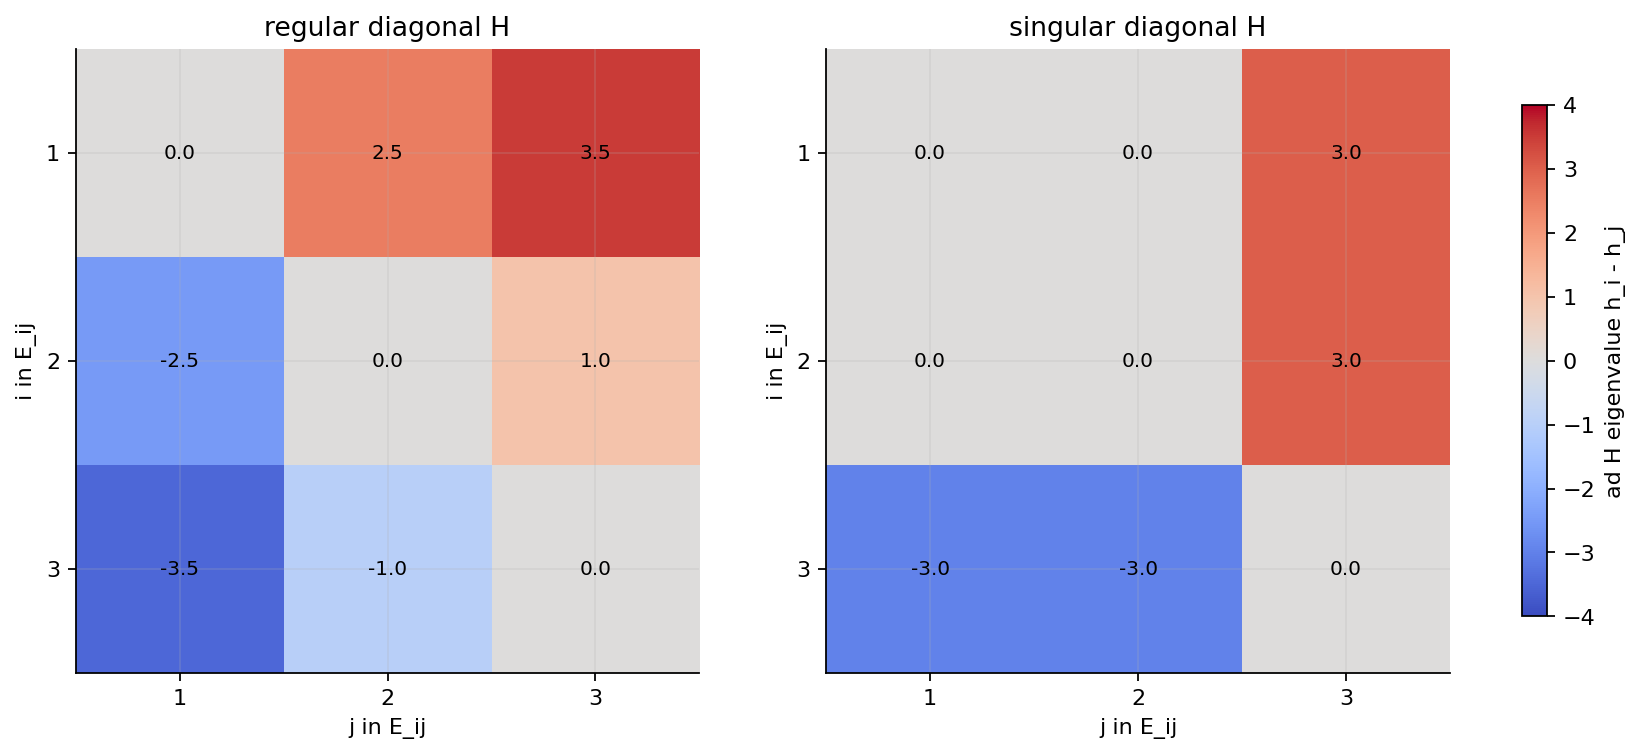

In [4]:
def ad_diagonal_weights(diagonal: np.ndarray) -> np.ndarray:
    return diagonal[:, None] - diagonal[None, :]

H_regular = np.array([2.0, -0.5, -1.5])
H_singular = np.array([1.0, 1.0, -2.0])
weights_regular = ad_diagonal_weights(H_regular)
weights_singular = ad_diagonal_weights(H_singular)

def sl3_centralizer_dimension(weights: np.ndarray) -> int:
    offdiag_zero = sum(1 for i in range(3) for j in range(3) if i != j and abs(weights[i, j]) < 1e-12)
    return 2 + offdiag_zero

centralizer_regular = sl3_centralizer_dimension(weights_regular)
centralizer_singular = sl3_centralizer_dimension(weights_singular)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6), constrained_layout=True)
for ax, data, title in zip(axes, [weights_regular, weights_singular], ["regular diagonal H", "singular diagonal H"]):
    im = ax.imshow(data, cmap="coolwarm", vmin=-4, vmax=4)
    ax.set_xticks(range(3), ["1", "2", "3"])
    ax.set_yticks(range(3), ["1", "2", "3"])
    ax.set_xlabel("j in E_ij")
    ax.set_ylabel("i in E_ij")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{data[i,j]:.1f}", ha="center", va="center", color="black", fontsize=9)
fig.colorbar(im, ax=axes, shrink=0.82, label="ad H eigenvalue h_i - h_j")
cartan_figure = record(save_matplotlib(fig, FIGURES / "sl3_regular_centralizer_heatmap.png"))
plt.close(fig)

cartan_rows = [
    {"case": "regular", "diagonal": str(H_regular.tolist()), "centralizer_dimension_in_sl3": centralizer_regular, "off_diagonal_zero_weights": centralizer_regular - 2},
    {"case": "singular", "diagonal": str(H_singular.tolist()), "centralizer_dimension_in_sl3": centralizer_singular, "off_diagonal_zero_weights": centralizer_singular - 2},
]
cartan_table = record(save_csv(cartan_rows, TABLES / "sl3_regular_centralizer_table.csv"))
cartan_report = record(save_json({
    "regular_weights": weights_regular.tolist(),
    "singular_weights": weights_singular.tolist(),
    "checks": {
        "regular_centralizer_has_cartan_dimension_two": centralizer_regular == 2,
        "singular_centralizer_is_larger": centralizer_singular > centralizer_regular,
    },
}, CHECKS / "sl3_cartan_regular_checks.json"))
chapter_checks["sl3_regular_centralizer_dimension_two"] = bool(centralizer_regular == 2)
chapter_checks["sl3_singular_centralizer_larger"] = bool(centralizer_singular > centralizer_regular)
print(json.dumps({"figure": rel(cartan_figure), "table": rel(cartan_table), "checks": rel(cartan_report)}, indent=2))
display_artifact(cartan_figure)


## 3. Root Space Decomposition: The `A2` Pattern

For `sl(3,C)`, the Cartan subalgebra consists of diagonal trace-zero matrices. Each off-diagonal matrix `E_ij` is a root vector, because `[H,E_ij]=(e_i(H)-e_j(H))E_ij`. The six nonzero roots form the `A2` hexagon, while the Cartan subalgebra contributes the zero root space.

This diagram is the chapter's root-space decomposition in its smallest nontrivial semisimple example.


{
  "figure": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/figures/sl3_a2_root_system.png",
  "table": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/tables/sl3_root_space_table.csv",
  "root_count": 6
}


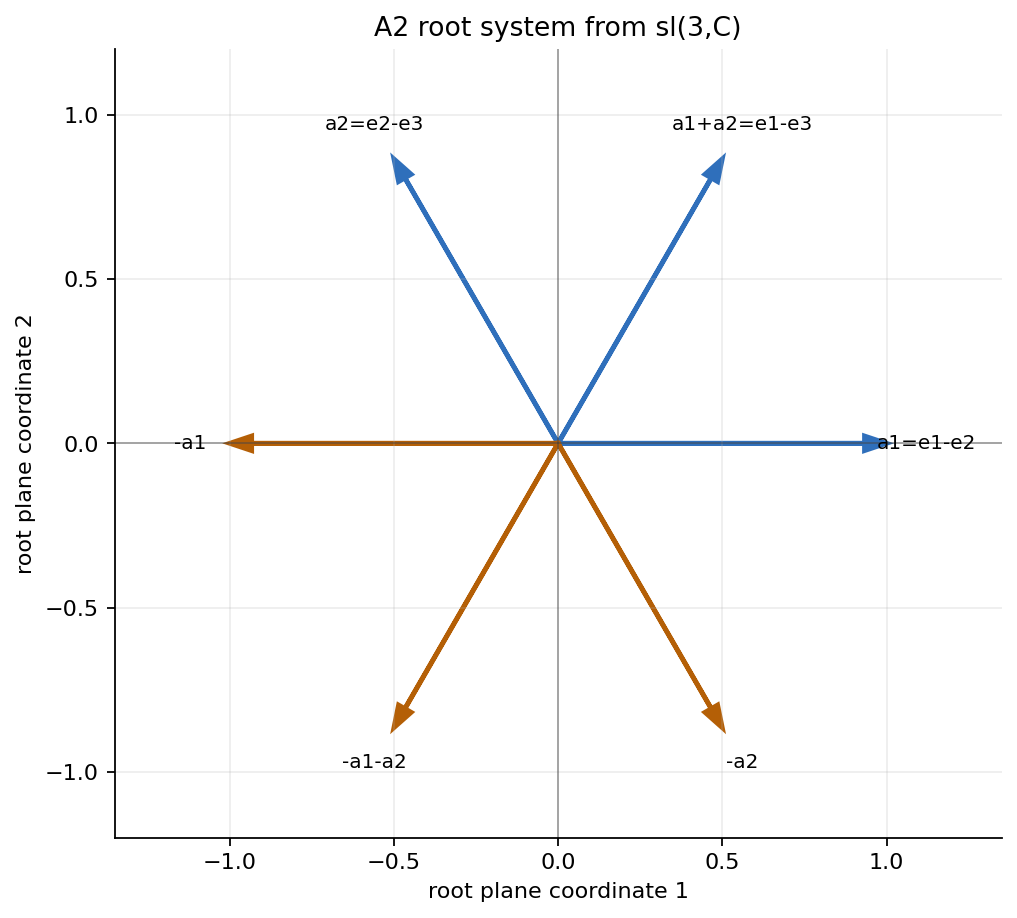

In [5]:
sqrt3 = math.sqrt(3)
alpha1 = np.array([1.0, 0.0])
alpha2 = np.array([-0.5, sqrt3 / 2])
roots_a2 = {
    "a1=e1-e2": alpha1,
    "a2=e2-e3": alpha2,
    "a1+a2=e1-e3": alpha1 + alpha2,
    "-a1": -alpha1,
    "-a2": -alpha2,
    "-a1-a2": -(alpha1 + alpha2),
}

fig, ax = plt.subplots(figsize=(7.2, 6.4))
for label, vec in roots_a2.items():
    color = "#2f6fbb" if not label.startswith("-") else "#b45f06"
    ax.arrow(0, 0, vec[0], vec[1], head_width=0.045, length_includes_head=True, color=color, linewidth=2.1)
    ax.text(vec[0] * 1.12, vec[1] * 1.12, label, ha="center", va="center", fontsize=9)
ax.axhline(0, color="#222222", linewidth=0.8, alpha=0.4)
ax.axvline(0, color="#222222", linewidth=0.8, alpha=0.4)
ax.set_aspect("equal")
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.2, 1.2)
ax.set_title("A2 root system from sl(3,C)")
ax.set_xlabel("root plane coordinate 1")
ax.set_ylabel("root plane coordinate 2")
root_figure = record(save_matplotlib(fig, FIGURES / "sl3_a2_root_system.png"))
plt.close(fig)

root_rows = [
    {"root": "e1-e2", "root_vector": "E12", "coordinates": str(alpha1.tolist())},
    {"root": "e2-e3", "root_vector": "E23", "coordinates": str(alpha2.tolist())},
    {"root": "e1-e3", "root_vector": "E13", "coordinates": str((alpha1 + alpha2).tolist())},
    {"root": "e2-e1", "root_vector": "E21", "coordinates": str((-alpha1).tolist())},
    {"root": "e3-e2", "root_vector": "E32", "coordinates": str((-alpha2).tolist())},
    {"root": "e3-e1", "root_vector": "E31", "coordinates": str((-(alpha1 + alpha2)).tolist())},
]
root_table = record(save_csv(root_rows, TABLES / "sl3_root_space_table.csv"))
chapter_checks["sl3_has_six_nonzero_roots"] = bool(len(root_rows) == 6)
print(json.dumps({"figure": rel(root_figure), "table": rel(root_table), "root_count": len(root_rows)}, indent=2))
display_artifact(root_figure)


## 4. Root Strings, Cartan Integers, and Reflections

The chapter proves strong restrictions on how roots sit in Euclidean space. For `A2`, the simple roots have Cartan matrix entries `2` on the diagonal and `-1` off the diagonal. Reflections in the hyperplanes perpendicular to simple roots permute the six roots. This is the finite geometry behind the root-pattern classification theorem.


{
  "figure": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/figures/a2_root_reflections.png",
  "checks": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/checks/a2_root_reflection_checks.json"
}


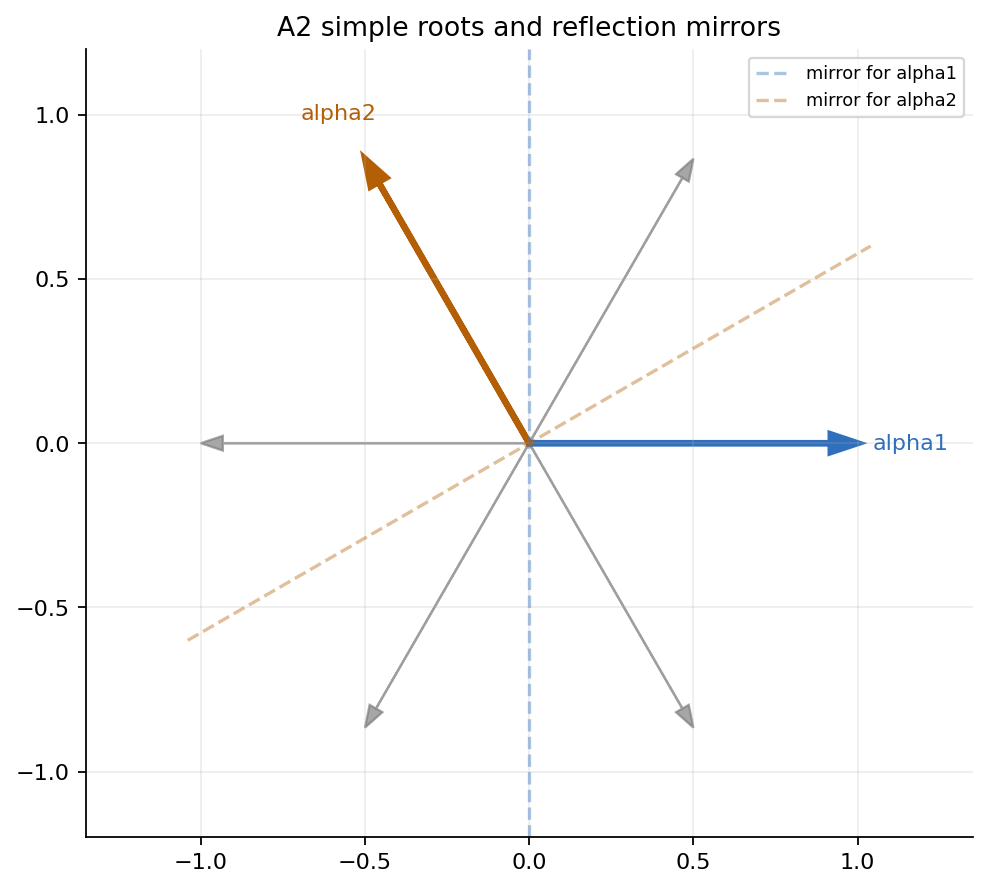

In [6]:
def cartan_integer(beta: np.ndarray, alpha: np.ndarray) -> int:
    return int(round(2 * float(np.dot(beta, alpha)) / float(np.dot(alpha, alpha))))

def reflect(beta: np.ndarray, alpha: np.ndarray) -> np.ndarray:
    return beta - 2 * np.dot(beta, alpha) / np.dot(alpha, alpha) * alpha

root_vectors = list(roots_a2.values())
root_array = np.array(root_vectors)
cartan_matrix = np.array([
    [cartan_integer(alpha1, alpha1), cartan_integer(alpha2, alpha1)],
    [cartan_integer(alpha1, alpha2), cartan_integer(alpha2, alpha2)],
], dtype=int)

def in_root_set(vec: np.ndarray, roots: np.ndarray, tol: float = 1e-8) -> bool:
    return any(np.linalg.norm(vec - root) < tol for root in roots)

reflection_checks = {}
for name, alpha in [("s_alpha1", alpha1), ("s_alpha2", alpha2)]:
    reflection_checks[name] = all(in_root_set(reflect(root, alpha), root_array) for root in root_array)

string_beta = alpha2
string_alpha = alpha1
string_members = []
for n in range(-3, 4):
    candidate = string_beta + n * string_alpha
    if in_root_set(candidate, root_array):
        string_members.append({"n": n, "coordinates": candidate.tolist()})

fig, ax = plt.subplots(figsize=(7.2, 6.4))
for root in root_array:
    ax.arrow(0, 0, root[0], root[1], head_width=0.045, length_includes_head=True, color="#777777", alpha=0.65)
for alpha, color, label in [(alpha1, "#2f6fbb", "alpha1"), (alpha2, "#b45f06", "alpha2")]:
    ax.arrow(0, 0, alpha[0], alpha[1], head_width=0.055, length_includes_head=True, color=color, linewidth=2.8)
    ax.text(alpha[0] * 1.16, alpha[1] * 1.16, label, color=color, ha="center", va="center")
line_x = np.linspace(-1.2, 1.2, 100)
ax.plot(np.zeros_like(line_x), line_x, color="#2f6fbb", linestyle="--", alpha=0.4, label="mirror for alpha1")
mirror2_dir = np.array([alpha2[1], -alpha2[0]])
mirror2 = np.outer(np.linspace(-1.2, 1.2, 100), mirror2_dir)
ax.plot(mirror2[:, 0], mirror2[:, 1], color="#b45f06", linestyle="--", alpha=0.4, label="mirror for alpha2")
ax.set_aspect("equal")
ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.2, 1.2)
ax.set_title("A2 simple roots and reflection mirrors")
ax.legend(fontsize=8)
reflection_figure = record(save_matplotlib(fig, FIGURES / "a2_root_reflections.png"))
plt.close(fig)

reflection_report = record(save_json({
    "cartan_matrix_simple_roots_alpha1_alpha2": cartan_matrix.tolist(),
    "alpha1_string_through_alpha2": string_members,
    "reflection_checks": reflection_checks,
    "checks": {
        "cartan_matrix_is_A2": bool(np.array_equal(cartan_matrix, np.array([[2, -1], [-1, 2]]))),
        "simple_reflections_preserve_roots": bool(all(reflection_checks.values())),
        "alpha1_string_through_alpha2_is_uninterrupted": [item["n"] for item in string_members] == [0, 1],
    },
}, CHECKS / "a2_root_reflection_checks.json"))
chapter_checks["a2_cartan_matrix_correct"] = bool(np.array_equal(cartan_matrix, np.array([[2, -1], [-1, 2]])))
chapter_checks["a2_reflections_preserve_root_set"] = bool(all(reflection_checks.values()))
chapter_checks["a2_root_string_uninterrupted"] = bool([item["n"] for item in string_members] == [0, 1])
print(json.dumps({"figure": rel(reflection_figure), "checks": rel(reflection_report)}, indent=2))
display_artifact(reflection_figure)


## 5. Root Pattern and Brackets

The theorem that the root pattern determines the complex semisimple Lie algebra depends on the way root spaces bracket: `[g_alpha,g_beta]` lands in `g_{alpha+beta}` when `alpha+beta` is a root, and vanishes when it is not. In `sl(3,C)`, ordinary matrix commutators make this rule concrete.


In [7]:
def Eij(i: int, j: int) -> sp.Matrix:
    M = sp.zeros(3)
    M[i, j] = 1
    return M

root_mats = {
    "e1-e2": Eij(0, 1),
    "e2-e3": Eij(1, 2),
    "e1-e3": Eij(0, 2),
    "e2-e1": Eij(1, 0),
    "e3-e2": Eij(2, 1),
    "e3-e1": Eij(2, 0),
}
root_pairs = {
    "e1-e2": (1, -1, 0),
    "e2-e3": (0, 1, -1),
    "e1-e3": (1, 0, -1),
    "e2-e1": (-1, 1, 0),
    "e3-e2": (0, -1, 1),
    "e3-e1": (-1, 0, 1),
}
pair_to_name = {value: key for key, value in root_pairs.items()}

commutator_rows = []
all_ok = True
for a_name, A in root_mats.items():
    for b_name, B in root_mats.items():
        if a_name >= b_name:
            continue
        bracket = A * B - B * A
        sum_tuple = tuple(root_pairs[a_name][i] + root_pairs[b_name][i] for i in range(3))
        expected = pair_to_name.get(sum_tuple)
        nonzero = bracket != sp.zeros(3)
        if expected is None and sum_tuple != (0, 0, 0):
            rule_ok = not nonzero
        elif expected is not None:
            rule_ok = nonzero and bracket in (root_mats[expected], -root_mats[expected])
        else:
            rule_ok = True
        all_ok = all_ok and bool(rule_ok)
        if nonzero or expected is not None:
            commutator_rows.append({
                "alpha": a_name,
                "beta": b_name,
                "alpha_plus_beta": expected if expected is not None else str(sum_tuple),
                "bracket_nonzero": bool(nonzero),
                "rule_ok": bool(rule_ok),
            })

commutator_table = record(save_csv(commutator_rows, TABLES / "sl3_root_commutator_table.csv"))
commutator_report = record(save_json({
    "rows": commutator_rows,
    "checks": {
        "root_brackets_follow_addition_rule": bool(all_ok),
        "E12_E23_brackets_to_E13": bool(root_mats["e1-e2"] * root_mats["e2-e3"] - root_mats["e2-e3"] * root_mats["e1-e2"] == root_mats["e1-e3"]),
    },
}, CHECKS / "sl3_root_commutator_checks.json"))
chapter_checks["sl3_root_brackets_follow_addition_rule"] = bool(all_ok)
chapter_checks["sl3_E12_E23_bracket_is_E13"] = bool(root_mats["e1-e2"] * root_mats["e2-e3"] - root_mats["e2-e3"] * root_mats["e1-e2"] == root_mats["e1-e3"])
print(json.dumps({"table": rel(commutator_table), "checks": rel(commutator_report), "rows": len(commutator_rows)}, indent=2))
display_artifact(commutator_table)


{
  "table": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/tables/sl3_root_commutator_table.csv",
  "checks": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/checks/sl3_root_commutator_checks.json",
  "rows": 9
}


[sl3_root_commutator_table.csv](artifacts/chapter-03-structure-of-semisimple-lie-algebras/tables/sl3_root_commutator_table.csv)

## 6. Real Forms and Cartan Decomposition in `sl(2,R)`

A Cartan decomposition splits a real semisimple algebra into compact directions `k` and noncompact directions `p`, controlled by a Cartan involution. For `sl(2,R)`, take `theta(X)=-X^T`. Then the skew-symmetric direction is the `+1` eigenspace `k`, while the symmetric trace-zero directions form the `-1` eigenspace `p`. The Killing form is negative on `k` and positive on `p`, and the brackets satisfy `[k,k] subset k`, `[k,p] subset p`, `[p,p] subset k`.


{
  "figure": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/figures/sl2_cartan_decomposition_signs.png",
  "table": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/tables/sl2_cartan_decomposition_signs.csv",
  "checks": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/checks/sl2_cartan_decomposition_checks.json"
}


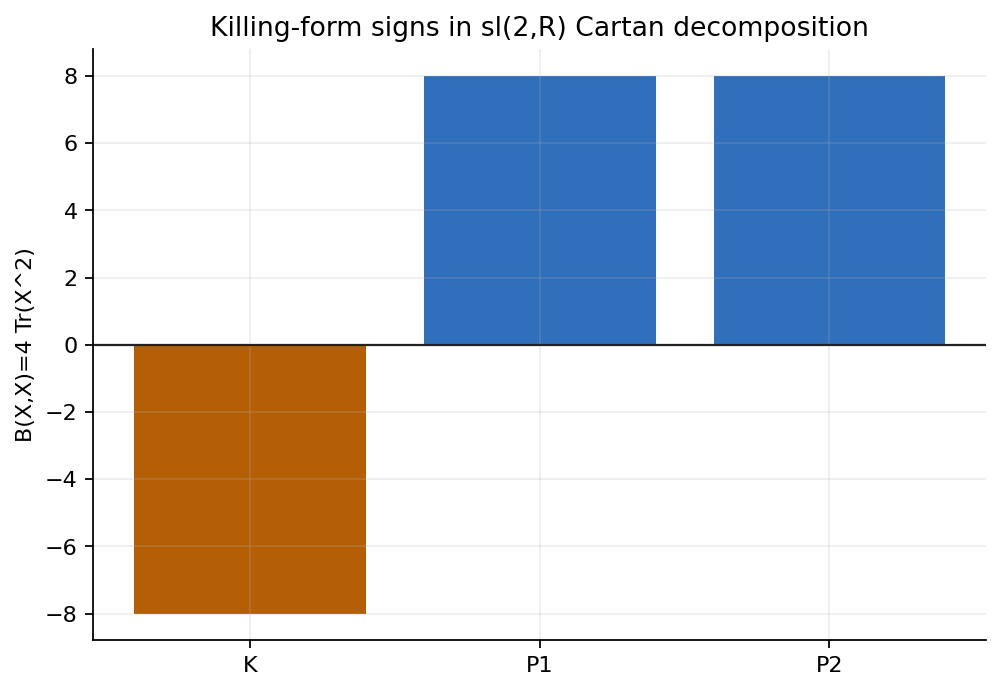

In [8]:
K = sp.Matrix([[0, 1], [-1, 0]])
P1 = sp.Matrix([[1, 0], [0, -1]])
P2 = sp.Matrix([[0, 1], [1, 0]])
sl2_basis = {"K": K, "P1": P1, "P2": P2}

def sl2_killing(A: sp.Matrix, B: sp.Matrix) -> sp.Expr:
    return sp.simplify(4 * sp.trace(A * B))

def theta(A: sp.Matrix) -> sp.Matrix:
    return -A.T

def bracket(A: sp.Matrix, B: sp.Matrix) -> sp.Matrix:
    return A * B - B * A

killing_rows = []
for name, M in sl2_basis.items():
    theta_eigen = "k (+1)" if theta(M) == M else "p (-1)"
    killing_rows.append({"basis": name, "theta_space": theta_eigen, "B(X,X)": str(sl2_killing(M, M))})
cartan_table = record(save_csv(killing_rows, TABLES / "sl2_cartan_decomposition_signs.csv"))

bracket_checks = {
    "k_k_subset_k": theta(bracket(K, K)) == bracket(K, K),
    "k_p_subset_p": theta(bracket(K, P1)) == -bracket(K, P1) and theta(bracket(K, P2)) == -bracket(K, P2),
    "p_p_subset_k": theta(bracket(P1, P2)) == bracket(P1, P2),
    "B_negative_on_k": sl2_killing(K, K) < 0,
    "B_positive_on_p": sl2_killing(P1, P1) > 0 and sl2_killing(P2, P2) > 0,
}

fig, ax = plt.subplots(figsize=(7.2, 4.8))
names = [row["basis"] for row in killing_rows]
values = [float(sp.sympify(row["B(X,X)"])) for row in killing_rows]
colors = ["#b45f06" if value < 0 else "#2f6fbb" for value in values]
ax.bar(names, values, color=colors)
ax.axhline(0, color="#222222", linewidth=1.0)
ax.set_title("Killing-form signs in sl(2,R) Cartan decomposition")
ax.set_ylabel("B(X,X)=4 Tr(X^2)")
cartan_decomp_figure = record(save_matplotlib(fig, FIGURES / "sl2_cartan_decomposition_signs.png"))
plt.close(fig)

cartan_decomp_report = record(save_json({
    "theta": "theta(X)=-X^T",
    "basis": killing_rows,
    "checks": {key: bool(value) for key, value in bracket_checks.items()},
}, CHECKS / "sl2_cartan_decomposition_checks.json"))
chapter_checks["sl2_cartan_bracket_relations_hold"] = bool(all(bracket_checks[key] for key in ["k_k_subset_k", "k_p_subset_p", "p_p_subset_k"]))
chapter_checks["sl2_cartan_killing_sign_split"] = bool(bracket_checks["B_negative_on_k"] and bracket_checks["B_positive_on_p"])
print(json.dumps({"figure": rel(cartan_decomp_figure), "table": rel(cartan_table), "checks": rel(cartan_decomp_report)}, indent=2))
display_artifact(cartan_decomp_figure)


## 7. Classical Complex Lie Algebras and Small Root Systems

The chapter ends by computing the root patterns for the complex classical Lie algebras. The formulas are uniform: type `A` comes from differences `e_i-e_j`; type `B` adds short roots `+-e_i`; type `C` uses `+-2e_i`; type `D` keeps only `+-e_i+-e_j`. The small diagrams below show the rank-two cases that fit naturally in the plane.


{
  "figure": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/figures/classical_rank2_root_systems.png",
  "table": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/tables/classical_root_system_counts.csv",
  "checks": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/checks/classical_root_system_checks.json"
}


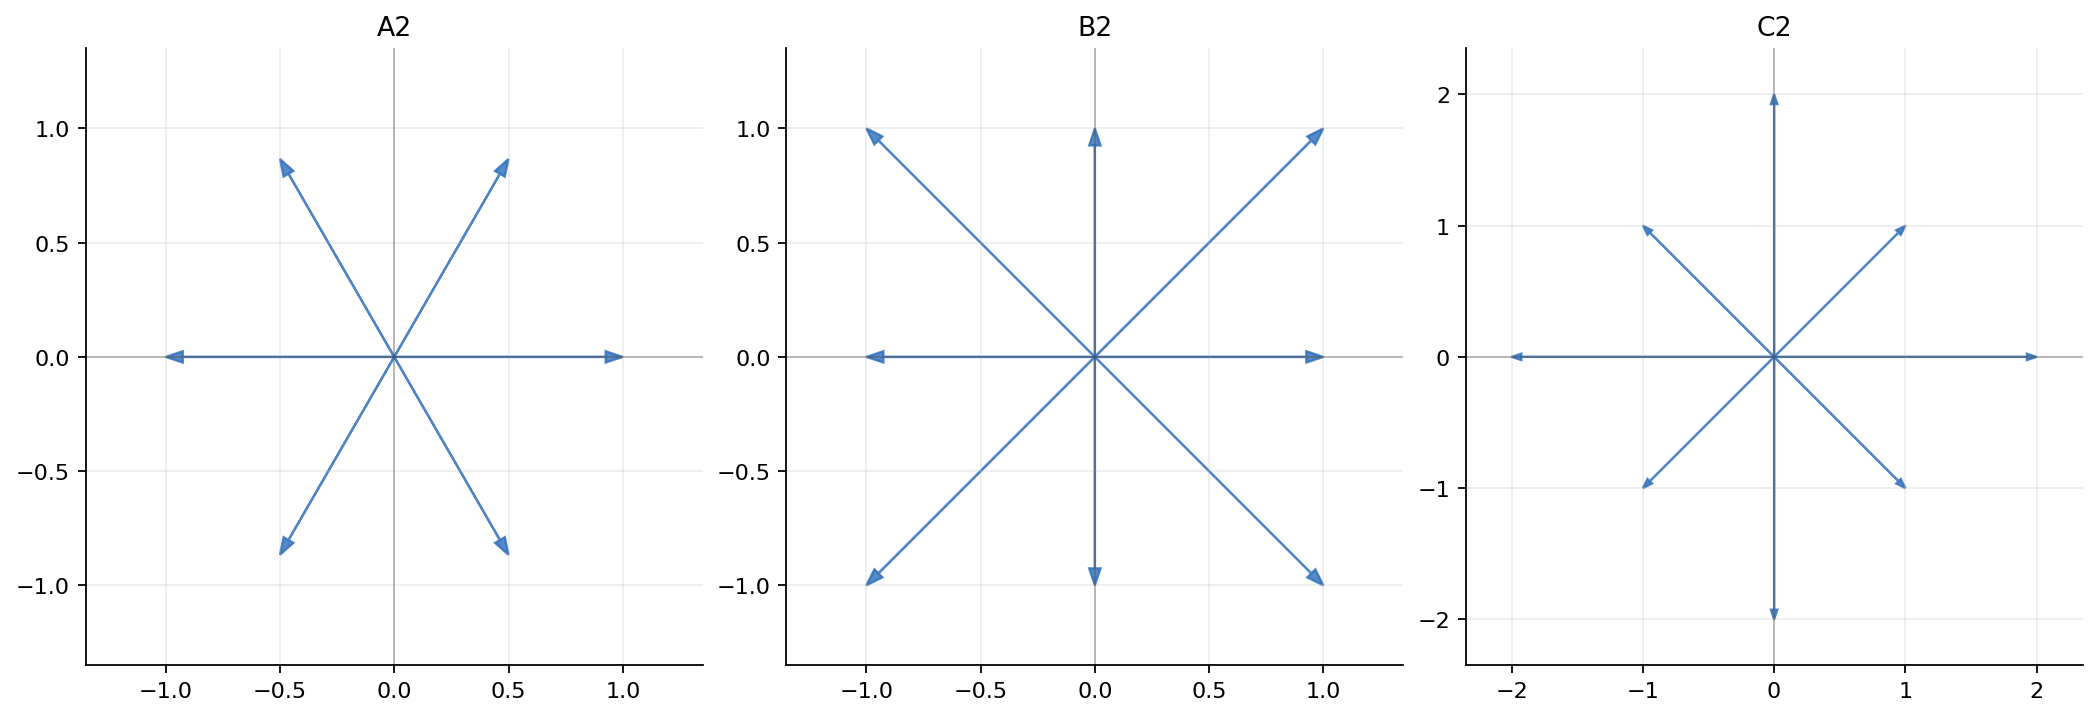

In [9]:
def roots_A2() -> np.ndarray:
    return np.array(list(roots_a2.values()))

def roots_B2() -> np.ndarray:
    roots = []
    for sx in [-1, 1]:
        roots.append([sx, 0])
        roots.append([0, sx])
    for sx in [-1, 1]:
        for sy in [-1, 1]:
            roots.append([sx, sy])
    return np.array(roots, dtype=float)

def roots_C2() -> np.ndarray:
    roots = []
    for sx in [-1, 1]:
        roots.append([2 * sx, 0])
        roots.append([0, 2 * sx])
    for sx in [-1, 1]:
        for sy in [-1, 1]:
            roots.append([sx, sy])
    return np.array(roots, dtype=float)

root_systems = {"A2": roots_A2(), "B2": roots_B2(), "C2": roots_C2()}
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), constrained_layout=True)
for ax, (name, roots) in zip(axes, root_systems.items()):
    for root in roots:
        ax.arrow(0, 0, root[0], root[1], head_width=0.05, length_includes_head=True, color="#2f6fbb", alpha=0.82)
    ax.set_title(name)
    ax.set_aspect("equal")
    lim = max(1.35, float(np.max(np.abs(roots))) + 0.35)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.axhline(0, color="#222222", linewidth=0.7, alpha=0.35)
    ax.axvline(0, color="#222222", linewidth=0.7, alpha=0.35)
classical_figure = record(save_matplotlib(fig, FIGURES / "classical_rank2_root_systems.png"))
plt.close(fig)

classical_rows = [
    {"type": "A_n", "roots": "e_i-e_j, i != j", "rank_n_sample": 2, "formula_count": "n(n+1)", "sample_count": len(root_systems["A2"])},
    {"type": "B_n", "roots": "+-e_i and +-e_i+-e_j", "rank_n_sample": 2, "formula_count": "2n^2", "sample_count": len(root_systems["B2"])},
    {"type": "C_n", "roots": "+-2e_i and +-e_i+-e_j", "rank_n_sample": 2, "formula_count": "2n^2", "sample_count": len(root_systems["C2"])},
    {"type": "D_n", "roots": "+-e_i+-e_j", "rank_n_sample": 4, "formula_count": "2n(n-1)", "sample_count": 24},
]
classical_table = record(save_csv(classical_rows, TABLES / "classical_root_system_counts.csv"))
classical_report = record(save_json({
    "sample_counts": {name: int(len(roots)) for name, roots in root_systems.items()},
    "checks": {
        "A2_has_six_roots": len(root_systems["A2"]) == 6,
        "B2_has_eight_roots": len(root_systems["B2"]) == 8,
        "C2_has_eight_roots": len(root_systems["C2"]) == 8,
        "D4_formula_count_is_24": 2 * 4 * (4 - 1) == 24,
    },
}, CHECKS / "classical_root_system_checks.json"))
chapter_checks["classical_A2_count_matches_formula"] = bool(len(root_systems["A2"]) == 6)
chapter_checks["classical_B2_count_matches_formula"] = bool(len(root_systems["B2"]) == 8)
chapter_checks["classical_C2_count_matches_formula"] = bool(len(root_systems["C2"]) == 8)
chapter_checks["classical_D4_count_matches_formula"] = bool(2 * 4 * (4 - 1) == 24)
print(json.dumps({"figure": rel(classical_figure), "table": rel(classical_table), "checks": rel(classical_report)}, indent=2))
display_artifact(classical_figure)


## Applied Lab: Change the Cartan Element or the Simple Roots

Two experiments are worth rerunning. First, change the diagonal entries in the `sl(3,C)` Cartan example. When two entries collide, additional off-diagonal root spaces move into the zero eigenspace, so the regular Cartan picture breaks. Second, replace the simple roots in the `A2` panel by another positive system. The root set is unchanged, but the list of positive roots and simple generators changes.

These two perturbations mirror the chapter's main cautions: regularity is an open condition, and root patterns are finite geometric objects with choices of ordering and simple system.


## Final Sanity and Artifact Check

The final checks assert the chapter-specific invariants: solvable and nilpotent chains terminate, regular Cartan centralizers have the expected dimension, the `A2` root system has the right finite geometry, root brackets follow addition, the Cartan decomposition has the correct bracket/sign behavior, and classical root-count formulas match small examples.


In [10]:
final_sanity = {
    "chapter": "Chapter III. Structure of Semisimple Lie Algebras",
    "source_span": "printed pages 155-197, approximately PDF pages 182-224",
    "artifact_count": len(artifact_paths),
    "artifacts": [rel(path) for path in artifact_paths],
    "checks": chapter_checks,
    "coverage_note": "Every major source block from Lie/Engel through classical root systems is represented by a visual, symbolic check, numerical finite model, or explicit coverage-ledger entry.",
}
failed = [name for name, value in chapter_checks.items() if isinstance(value, bool) and not value]
if failed:
    raise AssertionError(f"Chapter sanity checks failed: {failed}")
final_sanity_path = record(save_json(final_sanity, CHECKS / "final_sanity.json"))
assert_artifacts(artifact_paths, min_bytes=64)
assert_artifacts([final_sanity_path], min_bytes=64)
print(json.dumps({"final_sanity": rel(final_sanity_path), "boolean_checks": len([v for v in chapter_checks.values() if isinstance(v, bool)]), "failed": failed}, indent=2))
display_artifact(final_sanity_path)


{
  "final_sanity": "artifacts/chapter-03-structure-of-semisimple-lie-algebras/checks/final_sanity.json",
  "boolean_checks": 17,
  "failed": []
}


`final_sanity.json`

## Takeaways

Chapter III turns semisimple Lie algebras into finite root geometry. Lie's theorem and Engel's theorem explain why solvable and nilpotent pieces are triangular shadows rather than semisimple cores. Regular elements expose Cartan subalgebras, and Cartan subalgebras split the algebra into one-dimensional root spaces. Root strings, simple roots, Cartan integers, and reflections constrain the root pattern so strongly that the pattern determines the complex semisimple algebra.

The real-form sections explain how complex semisimple algebras interact with real geometry. Compact real forms give negative Killing form, while Cartan decompositions split real semisimple algebras into compact and noncompact directions. The classical examples make the classification concrete: types `A`, `B`, `C`, and `D` are read directly from their root formulas.
